In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from apad_puzzle.envs.apad_env import APADEnv, PIECES
import numpy as np

In [ ]:
env = APADEnv()

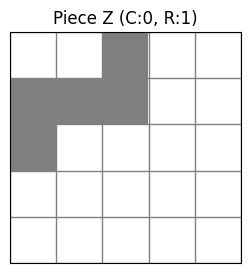

In [8]:
env.visualize_piece(env.encode_action(7,0,1,0))

# 8 pieces × 2 chirality × 4 rotations × 43 positions = 2752
# self.action_space = gym.spaces.Discrete(8 * 2 * 4 * 43)

In general, pieces can have 2 chirality configs and 4 rotations -> 8 actions. But let's be smarter and greatly reduce the action space.

- rectangle: 2 actions
- Z, C: 4 actions
- Knee, L, asp, I, P: 8 actions

$2752 - 6*43 - 8*43 = 2150$ Down from 2750, that's a 20% decrease.

In [12]:
6*43 + 8*43

602

In [7]:
2752 - 6*43 - 8*43

2150

And specifically, how do we identify these?

- rectangle: 2 actions. chirality = 0. rotation = 0 or 1.
- Z, C: 4 actions. chirality = 1 or 2. rotation = 0 or 1.
- Knee, L, asp, I, P: 8 actions

### keep going: not all positions allowed

In [11]:
env = APADEnv(-1,-1)
env.reset()
invalid_actions = []
for action in range(2751):
    move = env.decode_action(action)
    if not env._is_valid_placement(move['piece_id'],move['chirality'],move['rotation'],move['position']):
        invalid_actions.append(action)
print(f'n invalid actions {len(invalid_actions)}')

initial # of valid actions 0
initial # of unoccupied cells 43
initial # of available pieces 8
final # of valid actions 1363
total # of actions 2752
n invalid actions 1388


1388 actions are not valid due to positioning!

Including overlap with the above piece config removal, this is another significant reduction in the action space.

In [ ]:
import random

In [ ]:
action = random.choice(invalid_actions)
move = env.decode_action(action)
print(move['position'])
env.visualize_piece(action)

## Pre-filter action space. Have each env start with an action mask.

initial # of valid actions 0
initial # of unoccupied cells 43
initial # of available pieces 8
final # of valid actions 1041
total # of actions 2150
final # of valid actions 1041


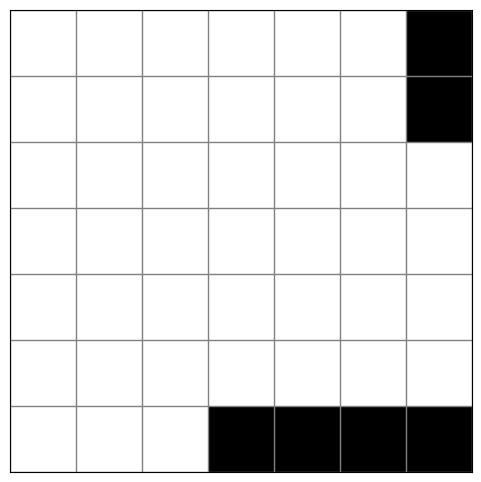

In [20]:
env = APADEnv(-1,-1)
mask = env.action_masks()
print(f'final # of valid actions {np.flatnonzero(mask).size}')
env.visualize()

# generate new action space

In [ ]:
env = APADEnv(-1,-1)
for piece_id in PIECES:
    for chirality in range(2):
        if env.piece_name[piece_id] == "R" and chirality = 1:
            continue
        for rotation in range(4):
            if env.piece_name[piece_id] in ["R", "Z", "C"] and rotation >= 2:
                continue
            for position in range(43):
                if env._is_valid_placement(
                    piece_id, chirality, rotation, position
                ):
                    action = self.encode_action(
                        piece_id, chirality, rotation, position
                    )
                    mask[action] = True

PIECES = {
    "K": [(0, 0), (1, 0), (2, 0), (3, 0), (2, 1)],  # __|_ knee           0-343
    "A": [(0, 0), (1, 0), (1, 1), (2, 1), (3, 1)],  # __|- Asp            344-686
    "C": [(0, 0), (0, 1), (1, 0), (2, 0), (2, 1)],  # C                   687-1030
    "L": [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2)],  # |__  L              1031-1374
    "R": [(0, 0), (0, 1), (1, 0), (1, 1), (2, 0), (2, 1)],  # [] rectangle  1375-1718
    "P": [(0, 0), (0, 1), (1, 0), (1, 1), (2, 0)],  # P                   1719-2062
    "I": [(0, 0), (0, 1), (1, 0), (2, 0), (3, 0)],  # |_ I                2063-2406
    "Z": [(0, 0), (0, 1), (1, 1), (2, 1), (2, 2)],  # Z                   2407-2751
}

base_coords = PIECES[self.piece_names[piece_id]]
self.piece_names = ["K", "A", "C", "L", "R", "P", "I", "Z"]

- rectangle: 2 actions. chirality = 0. rotation = 0 or 1.
- Z, C: 4 actions. chirality = 1 or 2. rotation = 0 or 1.
- Knee, L, asp, I, P: 8 actions
